# Módulo 2 — Métricas de Temporada
### Proyecto: Segmentación de Clientes en Centros Comerciales
**Materia:** Ciencia de Datos I  
**Institución:** ETITC  
**Autores:** Daniel Valencia, Daniel Medcalfe

En este módulo analizamos cómo varían las ventas a lo largo del tiempo para identificar épocas de alta y baja demanda.

## 1. Importar librerías

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## 2. Cargar datos

In [2]:
df = pd.read_csv('../../data/processed/datos_limpios.csv')
df['invoice_date'] = pd.to_datetime(df['invoice_date'])

# Excluir 2023 porque solo tiene datos hasta marzo
df = df[df['year'] < 2023].copy()

print("Período analizado:", df['invoice_date'].min().date(), "→", df['invoice_date'].max().date())
print("Transacciones:", len(df))

Período analizado: 2021-01-01 → 2022-12-31
Transacciones: 90933


## 3. Ingresos mensuales 2021 vs 2022

Comparamos los mismos meses entre ambos años para ver si hay crecimiento o caída.

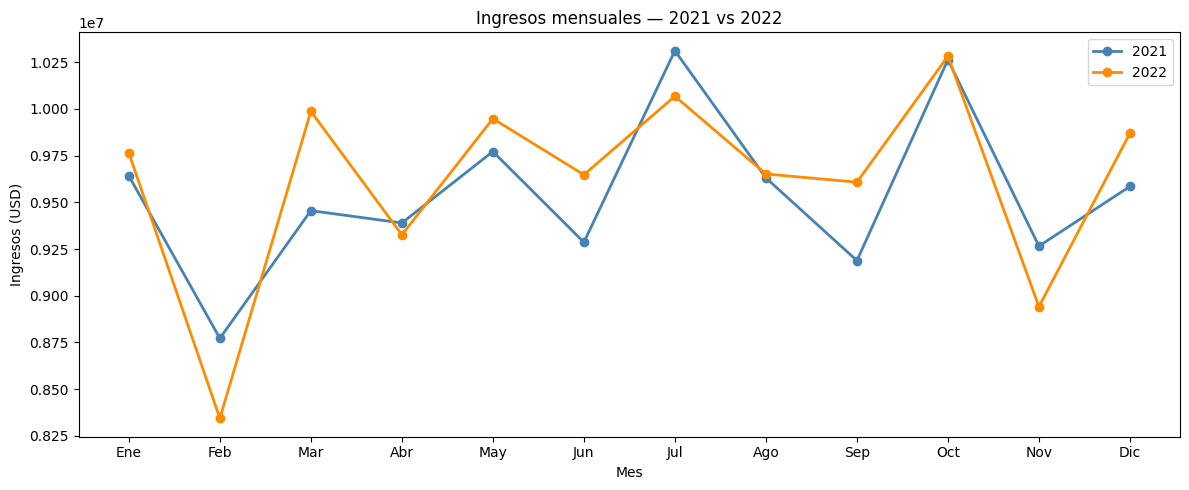

In [4]:
mensual = df.groupby(['year', 'month'])['total_spend'].sum().reset_index()

# Separar por año
m2021 = mensual[mensual['year'] == 2021].set_index('month')['total_spend']
m2022 = mensual[mensual['year'] == 2022].set_index('month')['total_spend']

meses = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

plt.figure(figsize=(12, 5))
plt.plot(meses, m2021.values, marker='o', label='2021', color='steelblue', linewidth=2)
plt.plot(meses, m2022.values, marker='o', label='2022', color='darkorange', linewidth=2)
plt.title('Ingresos mensuales — 2021 vs 2022')
plt.ylabel('Ingresos (USD)')
plt.xlabel('Mes')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../../reports/figures/temporada_comparativa.png')
plt.show()

## 4. Estacionalidad promedio por mes

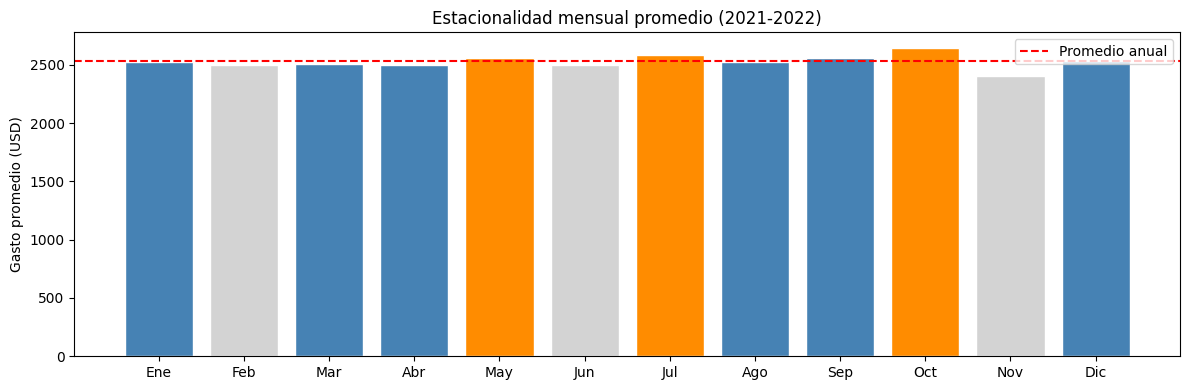

Ene: $2,526  →  Temporada Media
Feb: $2,497  →  Temporada Baja
Mar: $2,505  →  Temporada Media
Abr: $2,500  →  Temporada Media
May: $2,562  →  Temporada Alta
Jun: $2,498  →  Temporada Baja
Jul: $2,587  →  Temporada Alta
Ago: $2,526  →  Temporada Media
Sep: $2,556  →  Temporada Media
Oct: $2,646  →  Temporada Alta
Nov: $2,407  →  Temporada Baja
Dic: $2,533  →  Temporada Media


In [6]:
promedio_mes = df.groupby('month')['total_spend'].mean()

# Clasificar cada mes
def clasificar(val, q25, q75):
    if val >= q75:
        return 'Alta'
    elif val >= q25:
        return 'Media'
    else:
        return 'Baja'

q25 = promedio_mes.quantile(0.25)
q75 = promedio_mes.quantile(0.75)

colores_mes = []
for v in promedio_mes:
    clase = clasificar(v, q25, q75)
    if clase == 'Alta':
        colores_mes.append('darkorange')
    elif clase == 'Media':
        colores_mes.append('steelblue')
    else:
        colores_mes.append('lightgray')

plt.figure(figsize=(12, 4))
plt.bar(meses, promedio_mes.values, color=colores_mes, edgecolor='white')
plt.axhline(promedio_mes.mean(), color='red', linestyle='--', label='Promedio anual')
plt.title('Estacionalidad mensual promedio (2021-2022)')
plt.ylabel('Gasto promedio (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('../../reports/figures/temporada_estacionalidad.png')
plt.show()

# Tabla resumen
for i, (mes, val) in enumerate(zip(meses, promedio_mes)):
    clase = clasificar(val, q25, q75)
    print(f"{mes}: ${val:,.0f}  →  Temporada {clase}")

## 5. Ingresos por trimestre

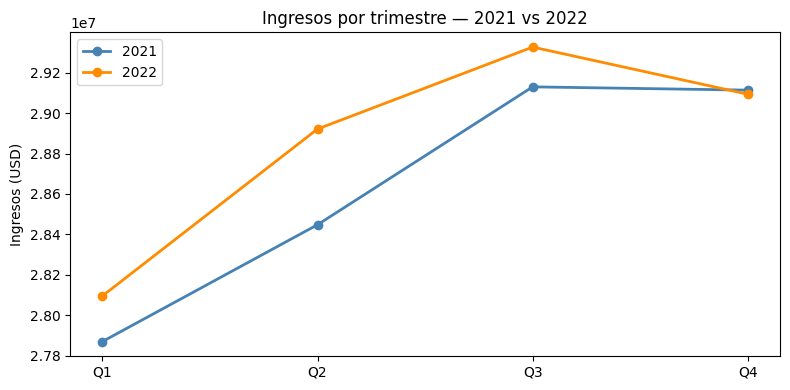

In [7]:
df['quarter'] = df['invoice_date'].dt.quarter

trimestral = df.groupby(['year', 'quarter'])['total_spend'].sum().reset_index()

q2021 = trimestral[trimestral['year'] == 2021].set_index('quarter')['total_spend']
q2022 = trimestral[trimestral['year'] == 2022].set_index('quarter')['total_spend']

x = ['Q1', 'Q2', 'Q3', 'Q4']

plt.figure(figsize=(8, 4))
plt.plot(x, q2021.values, marker='o', label='2021', color='steelblue', linewidth=2)
plt.plot(x, q2022.values, marker='o', label='2022', color='darkorange', linewidth=2)
plt.title('Ingresos por trimestre — 2021 vs 2022')
plt.ylabel('Ingresos (USD)')
plt.legend()
plt.tight_layout()
plt.savefig('../../reports/figures/temporada_trimestral.png')
plt.show()

## 6. ¿Qué día de la semana se compra más?

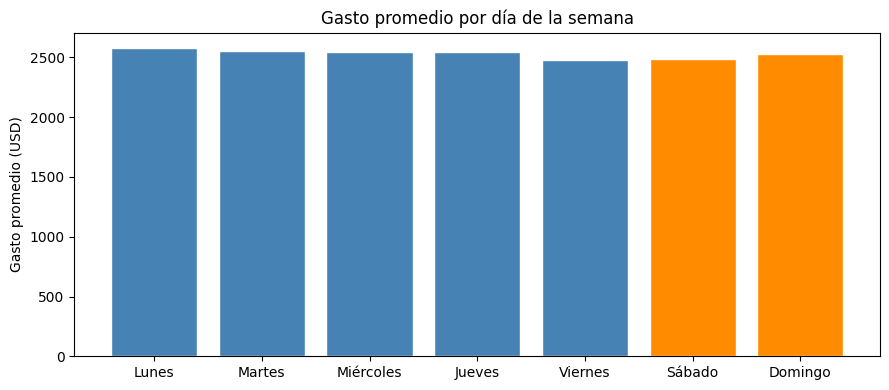

In [8]:
orden = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
nombres = ['Lunes','Martes','Miércoles','Jueves','Viernes','Sábado','Domingo']

dia = df.groupby('day_of_week')['total_spend'].mean().reindex(orden)

plt.figure(figsize=(9, 4))
colores_dia = ['darkorange' if d in ['Saturday','Sunday'] else 'steelblue' for d in orden]
plt.bar(nombres, dia.values, color=colores_dia, edgecolor='white')
plt.title('Gasto promedio por día de la semana')
plt.ylabel('Gasto promedio (USD)')
plt.tight_layout()
plt.savefig('../../reports/figures/temporada_dia_semana.png')
plt.show()

## 7. Resumen de hallazgos

In [9]:
mes_alto = meses[promedio_mes.idxmax() - 1]
mes_bajo = meses[promedio_mes.idxmin() - 1]

print("=" * 45)
print("RESUMEN — Módulo 2: Métricas de Temporada")
print("=" * 45)
print(f"Mes con más ventas  : {mes_alto}")
print(f"Mes con menos ventas: {mes_bajo}")
print()
print("Alta temporada  :", [meses[i] for i,v in enumerate(promedio_mes) if clasificar(v, q25, q75) == 'Alta'])
print("Temporada media :", [meses[i] for i,v in enumerate(promedio_mes) if clasificar(v, q25, q75) == 'Media'])
print("Temporada baja  :", [meses[i] for i,v in enumerate(promedio_mes) if clasificar(v, q25, q75) == 'Baja'])
print()
print("Gráficas guardadas en reports/figures/")

RESUMEN — Módulo 2: Métricas de Temporada
Mes con más ventas  : Oct
Mes con menos ventas: Nov

Alta temporada  : ['May', 'Jul', 'Oct']
Temporada media : ['Ene', 'Mar', 'Abr', 'Ago', 'Sep', 'Dic']
Temporada baja  : ['Feb', 'Jun', 'Nov']

Gráficas guardadas en reports/figures/
